# 03 — Pedal depth profiles at cadences (full corpus)

For all 36 movements, sample CC64 depth in a +/-2-beat window around each cadence,
normalise by local IBI, and average by cadence type.

Pedal-depth analogue of the local tempo analysis in Fig. 4 of Hu & Widmer (2023).

In [ ]:
import sys, os
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.interpolate import interp1d as scipy_interp1d
import partitura as pt, warnings
warnings.filterwarnings('ignore')
from layers import build_score_to_perf_map, build_beat_grid, beat_unit_from_timesig_str

DATASET  = 'path to Batik-plays-Mozart dataset directory (https://github.com/huispaty/batik_plays_mozart)'
BEAT_GRID = np.linspace(-2, 2, 81)

TIMESIGS = {
    'kv279_1':'4/4','kv279_2':'3/4','kv279_3':'2/4',
    'kv280_1':'3/4','kv280_2':'6/8','kv280_3':'3/8',
    'kv281_1':'2/4','kv281_2':'3/8','kv281_3':'2/2',
    'kv282_1':'4/4','kv282_2':'3/4','kv282_3':'2/4',
    'kv283_1':'3/4','kv283_2':'4/4','kv283_3':'3/8',
    'kv284_1':'4/4','kv284_2':'3/4','kv284_3':'3/4',
    'kv330_1':'2/4','kv330_2':'3/4','kv330_3':'2/4',
    'kv331_1':'6/8','kv331_2':'3/4','kv331_3':'2/4',
    'kv332_1':'3/4','kv332_2':'4/4','kv332_3':'6/8',
    'kv333_1':'4/4','kv333_2':'3/4','kv333_3':'2/2',
    'kv457_1':'4/4','kv457_2':'4/4','kv457_3':'3/4',
    'kv533_1':'2/2','kv533_2':'3/4','kv533_3':'2/2',
}

## Collect depth profiles across all 36 movements

In [2]:
def load_movement(mv):
    perf, alignment, score = pt.load_match(
        f'{DATASET}/match/{mv}.match', create_score=True)
    sna = score.note_array(); pna = perf.note_array(); pp = perf.performedparts[0]
    cc64 = sorted([c for c in pp.controls if c['number']==64], key=lambda c: c['time'])
    if len(cc64) < 10: return None
    t_cc = np.array([c['time']  for c in cc64])
    v_cc = np.array([c['value'] for c in cc64]) / 127.0
    cc64_interp = scipy_interp1d(t_cc, v_cc, kind='previous',
                                  bounds_error=False, fill_value=(v_cc[0], v_cc[-1]))
    bu = beat_unit_from_timesig_str(TIMESIGS.get(mv, '4/4'))
    q2t = build_score_to_perf_map(sna, pna, alignment)
    _, beat_ts = build_beat_grid(sna, q2t, beat_unit=bu)
    return cc64_interp, q2t, beat_ts

movements = sorted([f.replace('.match','') for f in os.listdir(f'{DATASET}/match')
                    if f.endswith('.match') and not f.startswith('.')])

corpus_curves = {}   # cadence_type -> [arrays]
sonata_curves = {}   # (sonata, ct) -> [arrays]
skipped = []

for mv in movements:
    ann_path = f'{DATASET}/score_parts_annotated/{mv}_spart_cadence.csv'
    if not os.path.exists(ann_path): skipped.append(mv); continue
    sonata = mv.rsplit('_', 1)[0]
    try:
        result = load_movement(mv)
        if result is None: skipped.append(mv); continue
        cc64_interp, q2t, beat_ts = result
        df_cad = pd.read_csv(ann_path)
        cad_rows = df_cad[
            df_cad['cadence'].notna() &
            (df_cad['cadence'] != '0') & (df_cad['cadence'] != 0)
        ].drop_duplicates(subset=['onset_quarter','cadence'])
        for _, row in cad_rows.iterrows():
            ct    = row['cadence']
            t_cad = float(q2t(float(row['onset_quarter'])))
            idx   = int(np.argmin(np.abs(beat_ts - t_cad)))
            if not (0 < idx < len(beat_ts) - 1): continue
            ibi = (beat_ts[idx+1] - beat_ts[idx-1]) / 2.0
            if ibi < 0.05: continue
            curve = cc64_interp(t_cad + BEAT_GRID * ibi)
            corpus_curves.setdefault(ct, []).append(curve)
            sonata_curves.setdefault((sonata, ct), []).append(curve)
    except Exception as e:
        skipped.append(f'{mv}: {e}')

print('Cadences per type:')
for ct, curves in sorted(corpus_curves.items(), key=lambda x: -len(x[1])):
    print(f'  {ct:5s}: {len(curves):3d}')
if skipped: print('Skipped:', skipped)

Cadences per type:
  PAC  : 547
  HC   : 410
  IAC  :  75
  EC   :  65
  DC   :  47


## Main result: mean depth profile per cadence type

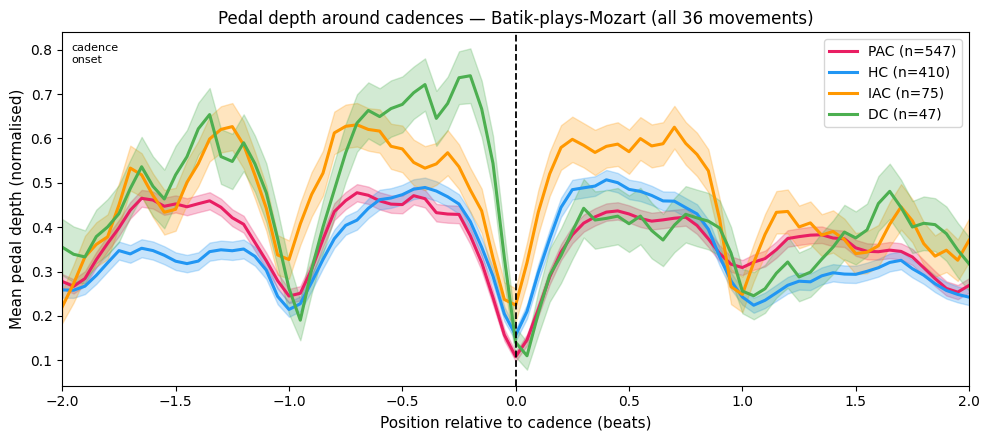

In [3]:
COLORS = {'PAC':'#E91E63','HC':'#2196F3','IAC':'#FF9800','DC':'#4CAF50'}
FOCUS  = [ct for ct in ['PAC','HC','IAC','DC']
          if ct in corpus_curves and len(corpus_curves[ct]) >= 3]

fig, ax = plt.subplots(figsize=(10, 4.5))
for ct in FOCUS:
    arr  = np.array(corpus_curves[ct])
    mean = arr.mean(0)
    sem  = arr.std(0) / np.sqrt(len(arr))
    ax.plot(BEAT_GRID, mean, lw=2.2, color=COLORS[ct], label=f'{ct} (n={len(arr)})')
    ax.fill_between(BEAT_GRID, mean-sem, mean+sem, alpha=0.25, color=COLORS[ct])

ax.axvline(0, color='k', lw=1.3, ls='--')
ax.text(0.01, 0.97, 'cadence\nonset', transform=ax.transAxes, va='top', fontsize=8)
ax.set_xlabel('Position relative to cadence (beats)', fontsize=11)
ax.set_ylabel('Mean pedal depth (normalised)', fontsize=11)
ax.set_title('Pedal depth around cadences — Batik-plays-Mozart (all 36 movements)', fontsize=12)
ax.set_xlim(-2, 2); ax.legend(fontsize=10)
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/cadence_depth_profiles.pdf', bbox_inches='tight')
plt.show()

## Summary table: depth at key beat positions

In [4]:
summary = []
for ct, curves in corpus_curves.items():
    arr = np.array(curves)
    summary.append({
        'cadence_type': ct, 'n': len(arr),
        'depth_-2beat': round(arr[:,  0].mean(), 3),
        'depth_-1beat': round(arr[:, 20].mean(), 3),
        'depth_onset':  round(arr[:, 40].mean(), 3),
        'depth_+1beat': round(arr[:, 60].mean(), 3),
        'depth_+2beat': round(arr[:, 80].mean(), 3),
    })
df_summary = pd.DataFrame(summary).sort_values('n', ascending=False).set_index('cadence_type')
print(df_summary.to_string())

                n  depth_-2beat  depth_-1beat  depth_onset  depth_+1beat  depth_+2beat
cadence_type                                                                          
PAC           547         0.278         0.245        0.108         0.309         0.269
HC            410         0.259         0.214        0.157         0.243         0.242
IAC            75         0.221         0.327        0.224         0.248         0.370
EC             65         0.300         0.168        0.155         0.233         0.180
DC             47         0.355         0.262        0.140         0.256         0.317


## PAC profiles per sonata

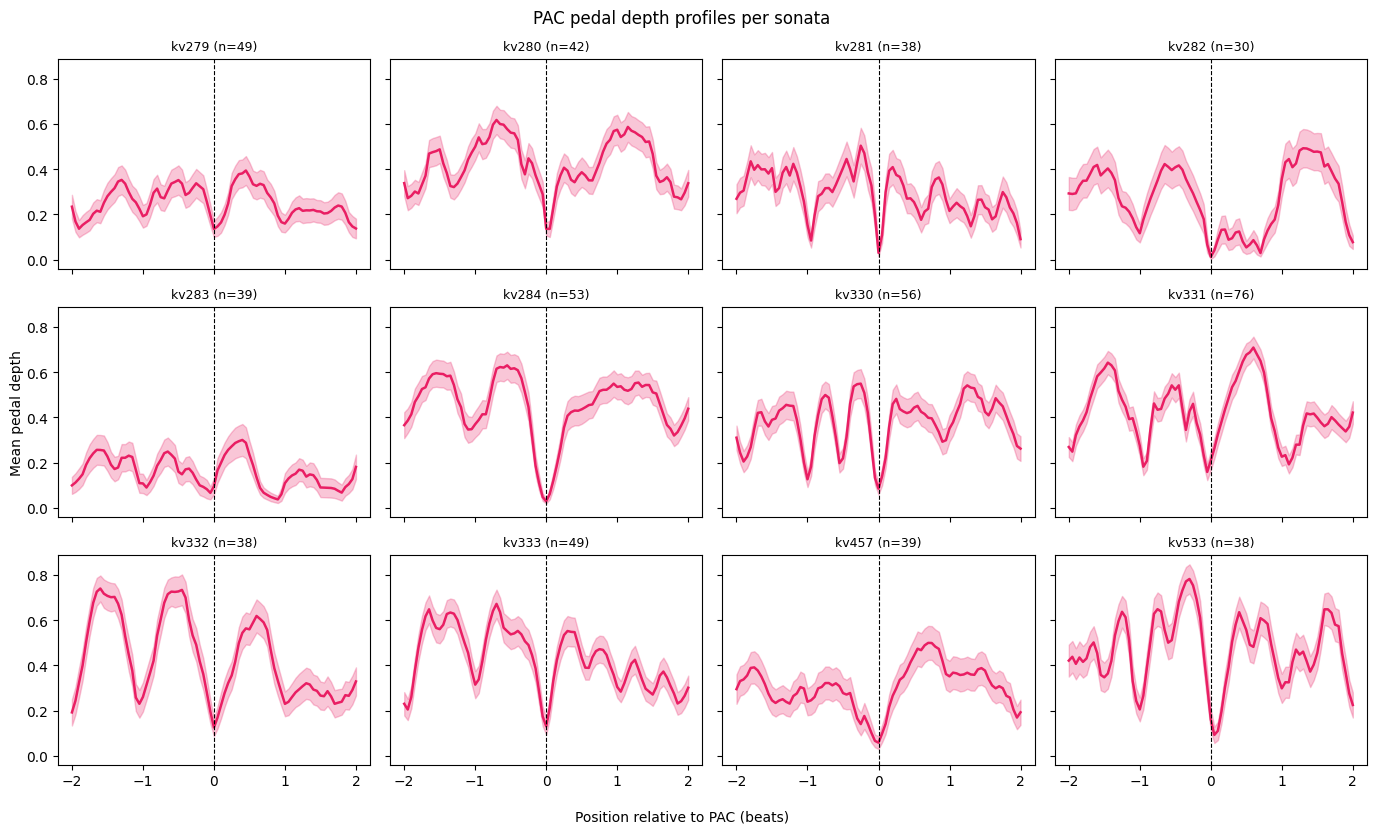

In [5]:
pac_sonatas = [(s, curves) for (s, ct), curves in sonata_curves.items()
               if ct == 'PAC' and len(curves) >= 2]
pac_sonatas.sort(key=lambda x: x[0])

cols = 4; rows = -(-len(pac_sonatas) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, rows*2.8), sharex=True, sharey=True)
axes = axes.flatten()
for i, (sonata, curves) in enumerate(pac_sonatas):
    arr = np.array(curves)
    mean = arr.mean(0); sem = arr.std(0)/np.sqrt(len(arr))
    axes[i].plot(BEAT_GRID, mean, lw=1.8, color='#E91E63')
    axes[i].fill_between(BEAT_GRID, mean-sem, mean+sem, alpha=0.25, color='#E91E63')
    axes[i].axvline(0, color='k', lw=0.8, ls='--')
    axes[i].set_title(f'{sonata} (n={len(curves)})', fontsize=9)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.supxlabel('Position relative to PAC (beats)', fontsize=10)
fig.supylabel('Mean pedal depth', fontsize=10)
fig.suptitle('PAC pedal depth profiles per sonata', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/PAC_by_sonata.pdf', bbox_inches='tight')
plt.show()